In [ ]:
# Imports

from abc import ABC, abstractmethod
from dataclasses import dataclass
from collections import deque
from typing import Any, Dict, Iterable, List, Optional, Tuple
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches

In [ ]:
# Abstract Problem Interface

class Problem(ABC):
    """Abstract base class for a search problem."""

    @abstractmethod
    def initial_state(self) -> Any:
        """Return the start state."""
        pass

    @abstractmethod
    def is_goal(self, state: Any) -> bool:
        """Return True if state is a goal state."""
        pass

    @abstractmethod
    def actions(self, state: Any) -> List[Any]:
        """Return the legal actions available in the given state."""
        pass

    @abstractmethod
    def result(self, state: Any, action: Any) -> Any:
        """Return the next state after applying action in state."""
        pass

    @abstractmethod
    def action_cost(self, state: Any, action: Any, next_state: Any) -> float:
        """Return the cost of applying action in state to reach next_state."""
        pass

In [ ]:
# Node and SearchResult classes which are essentially data structures
# with a decorator "dataclass" to automatically include methods such as __rep__()
@dataclass
class Node:
    state: Any
    parent: Optional["Node"] = None
    action: Optional[Any] = None
    path_cost: float = 0
    depth: int = 0

    def __post_init__(self):
        if self.parent is not None:
            self.depth = self.parent.depth + 1


@dataclass
class SearchResult:
    algorithm: str
    status: str
    solution: Optional[Node]
    nodes_expanded: int
    max_frontier_size: int
    reached_count: int = 0
    limit: Optional[int] = None
    iterations: Optional[List[Dict[str, Any]]] = None

    @property
    def path(self) -> Optional[List[Any]]:
        if self.solution is None:
            return None
        return reconstruct_path(self.solution)

    @property
    def solution_depth(self) -> Optional[int]:
        if self.solution is None:
            return None
        return self.solution.depth

    @property
    def solution_cost(self) -> Optional[float]:
        if self.solution is None:
            return None
        return self.solution.path_cost








In [ ]:
# HELPER FUNCTIONS

def reconstruct_path(node: Node) -> List[Any]:
    """Return the list of states from the root node to this node."""
    path = []

    while node is not None:
        path.append(node.state)
        node = node.parent

    path.reverse()
    return path


def reconstruct_actions(node: Node) -> List[Any]:
    """Return the list of actions from the root node to this node."""
    actions = []

    while node is not None and node.parent is not None:
        actions.append(node.action)
        node = node.parent

    actions.reverse()
    return actions


def state_is_on_path(node: Node, state: Any) -> bool:
    """
    Return True if state already appears on the path from the root to node.

    This is useful for depth-limited search because DLS often uses path-cycle
    checking instead of a global reached set.
    """
    while node is not None:
        if node.state == state:
            return True
        node = node.parent

    return False


def result_to_row(result: SearchResult) -> Dict[str, Any]:
    """Convert a SearchResult object into a row for a pandas DataFrame."""
    return {
        "Algorithm": result.algorithm,
        "Status": result.status,
        "Limit": result.limit,
        "Solution depth": result.solution_depth,
        "Solution cost": result.solution_cost,
        "Nodes expanded": result.nodes_expanded,
        "Max frontier/stack": result.max_frontier_size,
        "Reached states": result.reached_count,
    }


def show_results(results: List[SearchResult]) -> pd.DataFrame:
    """Display results as a DataFrame."""
    return pd.DataFrame([result_to_row(r) for r in results])

In [ ]:
MOVES = {
    "UP": (-1, 0),
    "DOWN": (1, 0),
    "LEFT": (0, -1),
    "RIGHT": (0, 1),
}


class GridProblem(Problem):
    def __init__(
        self,
        grid: List[List[int]],
        start: Tuple[int, int],
        goal: Tuple[int, int],
    ):
        """
        grid:
            2D list where 0 = free cell and 1 = obstacle.

        start, goal:
            Tuples in the form (row, col).
        """
        self.grid = grid
        self.start = start
        self.goal = goal

        self.rows = len(grid)
        self.cols = len(grid[0])

    def initial_state(self) -> Tuple[int, int]:
        return self.start

    def is_goal(self, state: Tuple[int, int]) -> bool:

        return state == self.goal


    def in_bounds(self, state: Tuple[int, int]) -> bool:
        row, col = state
        return 0 <= row < self.rows and 0 <= col < self.cols

    def is_free(self, state: Tuple[int, int]) -> bool:
        row, col = state
        return self.grid[row][col] == 0

    def actions(self, state: Tuple[int, int]) -> List[str]:

        legal_actions = []

        for name, move in MOVES.items():
          action = tuple(np.array(state) + np.array(move))

          if self.in_bounds(action) and self.is_free(action):
            legal_actions.append(name)

        return legal_actions

    def result(self, state: Tuple[int, int], action: str) -> Tuple[int, int]:

        row, col = state
        dr, dc = MOVES[action]

        return (row + dr, col + dc)


    def action_cost(
        self,
        state: Tuple[int, int],
        action: str,
        next_state: Tuple[int, int],
    ) -> float:

        return 1.0



In [ ]:

# Assertion tests to evaluate functionality of GridProblem class
test_grid = [
    [0, 0, 0],
    [1, 1, 0],
    [0, 0, 0],
]

test_problem = GridProblem(test_grid, start=(0, 0), goal=(2, 2))

assert test_problem.initial_state() == (0, 0)
assert test_problem.is_goal((2, 2)) is True
assert test_problem.is_goal((0, 0)) is False
assert test_problem.actions((0, 0)) == ["RIGHT"]
assert test_problem.result((0, 0), "RIGHT") == (0, 1)
assert test_problem.action_cost((0, 0), "RIGHT", (0, 1)) == 1

print("GridProblem self-check passed.")



GridProblem self-check passed.


In [ ]:

# Sample grid to help testing
sample_grid = [
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
    [1, 1, 1, 0, 1, 0, 1, 1, 1, 0],
    [0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
    [0, 1, 1, 1, 1, 0, 1, 0, 1, 1],
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
    [0, 1, 1, 0, 1, 1, 1, 1, 1, 0],
    [0, 0, 1, 0, 0, 0, 0, 0, 1, 0],
    [1, 0, 1, 1, 1, 1, 1, 0, 1, 0],
    [0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
    [0, 1, 1, 1, 1, 0, 0, 0, 1, 0],
]

start = (0, 0)
goal = (9, 9)

problem = GridProblem(sample_grid, start, goal)



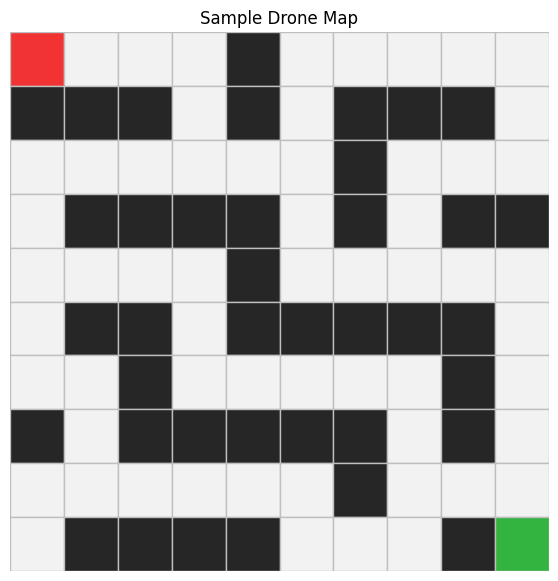

In [ ]:
# Visualization Function
def plot_path(
    grid: List[List[int]],
    start: Optional[Tuple[int, int]] = None,
    goal: Optional[Tuple[int, int]] = None,
    path: Optional[List[Tuple[int, int]]] = None,
    terrain_costs: Optional[List[List[float]]] = None,
    title: str = "Grid Map",
):
    """Visualise a grid and, optionally, a solution path."""
    arr = np.array(grid)
    height, width = arr.shape

    path_set = set(path) if path is not None else set()

    fig, ax = plt.subplots(figsize=(7, 7))
    ax.set_xlim(0, width)
    ax.set_ylim(height, 0)
    ax.set_aspect("equal")
    ax.axis("off")
    ax.set_title(title)

    for row in range(height):
        for col in range(width):
            state = (row, col)

            if arr[row, col] == 1:
                fill = (0.15, 0.15, 0.15)
            elif start is not None and state == start:
                fill = (0.95, 0.20, 0.20)
            elif goal is not None and state == goal:
                fill = (0.20, 0.70, 0.25)
            elif state in path_set:
                fill = (0.95, 0.90, 0.35)
            else:
                fill = (0.95, 0.95, 0.95)

            rect = patches.Rectangle(
                (col, row),
                1,
                1,
                linewidth=1,
                edgecolor=(0.75, 0.75, 0.75),
                facecolor=fill,
            )
            ax.add_patch(rect)

            if terrain_costs is not None and arr[row, col] == 0:
                ax.text(
                    col + 0.5,
                    row + 0.5,
                    str(terrain_costs[row][col]),
                    ha="center",
                    va="center",
                    fontsize=8,
                )

    plt.show()


plot_path(sample_grid, start, goal, title="Sample Drone Map")

In [ ]:
# Primary Searching Algorithm Class
class SearchAlgorithm(ABC):
    """Base class for search algorithms."""

    def expand(self, problem: Problem, node: Node) -> Iterable[Node]:

        s = node.state
        for action in problem.actions(s):
          s_prime = problem.result(s, action)
          cost = node.path_cost + problem.action_cost(s, action, s_prime)

          yield Node(state = s_prime, parent = node, action = action, path_cost = cost)

    @abstractmethod
    def search(self, problem: Problem) -> SearchResult:
        pass

In [ ]:
class BreadthFirstSearch(SearchAlgorithm):
    def search(self, problem: Problem) -> SearchResult:
        algorithm = "BFS"

        nodes_expanded = 0
        max_frontier_size = 1
        initial_node = Node(state = problem.initial_state())

        if problem.is_goal(initial_node.state):
          return SearchResult(
              algorithm = algorithm,
              status = "success",
              solution = initial_node,
              nodes_expanded = nodes_expanded,
              max_frontier_size = max_frontier_size,
              reached_count = 1
          )


        frontier = deque([initial_node])

        reached_set = set()
        reached_set.add(initial_node.state)


        while len(frontier) != 0:
          node = frontier.popleft()
          nodes_expanded += 1

          children = self.expand(problem, node)

          for child in children:
            if child.state not in reached_set:
              reached_set.add(child.state)
              frontier.append(child)
              max_frontier_size = max(max_frontier_size, len(frontier))

              if problem.is_goal(child.state):
                return SearchResult(
                algorithm = algorithm,
                status = "success",
                solution = child,
                nodes_expanded = nodes_expanded,
                max_frontier_size = max_frontier_size,
                reached_count = len(reached_set)
                )

        return SearchResult(
            algorithm = algorithm,
            status = "failure",
            solution = None,
            nodes_expanded = nodes_expanded,
            max_frontier_size = max_frontier_size,
            reached_count = len(reached_set)
            )

In [ ]:
class DepthFirstSearch(SearchAlgorithm):
    def search(self, problem: Problem) -> SearchResult:
        algorithm = "DFS"

        nodes_expanded = 0
        max_frontier_size = 1
        initial_node = Node(state = problem.initial_state())

        if problem.is_goal(initial_node.state):
          return SearchResult(
              algorithm = algorithm,
              status = "success",
              solution = initial_node,
              nodes_expanded = nodes_expanded,
              max_frontier_size = max_frontier_size,
              reached_count = 1
          )

        frontier = [initial_node]
        reached_set = {initial_node.state}

        while len(frontier) != 0:
          node = frontier.pop()
          nodes_expanded += 1

          children = list(self.expand(problem, node))
          children.reverse()

          for child in children:
            if child.state not in reached_set:
              reached_set.add(child.state)
              frontier.append(child)
              max_frontier_size = max(max_frontier_size, len(frontier))

              if problem.is_goal(child.state):
                return SearchResult(
                algorithm = algorithm,
                status = "success",
                solution = child,
                nodes_expanded = nodes_expanded,
                max_frontier_size = max_frontier_size,
                reached_count = len(reached_set)
                )

        return SearchResult(
              algorithm = algorithm,
              status = "failure",
              solution = None,
              nodes_expanded = nodes_expanded,
              max_frontier_size = max_frontier_size,
              reached_count = len(reached_set)
        )





In [ ]:
class DepthLimitedSearch(SearchAlgorithm):
    def search(self, problem: Problem, limit: int = 10) -> SearchResult:
        algorithm = "DLS"

        initial_node = Node(problem.initial_state())

        metrics = {
            "nodes_expanded": 0,
            "max_stack_size": 1,
        }

        solution, status = self._recursive_dls(
            problem=problem,
            node=initial_node,
            limit=limit,
            metrics=metrics,
            current_stack_size=1,
        )

        return SearchResult(
            algorithm=algorithm,
            status=status,
            solution=solution,
            nodes_expanded=metrics["nodes_expanded"],
            max_frontier_size=metrics["max_stack_size"],
            reached_count=0,
            limit=limit,
        )

    def _recursive_dls(
        self,
        problem: Problem,
        node: Node,
        limit: int,
        metrics: Dict[str, int],
        current_stack_size: int,
      ) -> Tuple[Optional[Node], str]:

      metrics["max_stack_size"] = max(metrics["max_stack_size"], current_stack_size)

      if problem.is_goal(node.state):
        return (node, "success")

      elif node.depth >= limit:
        return (None, "cutoff")

      else:
        metrics["nodes_expanded"] += 1
        cutoff_occurred = False

        children = self.expand(problem, node)
        for child in children:
            if state_is_on_path(node, child.state):
              continue

            result_node, status = self._recursive_dls(
                problem, child, limit, metrics, current_stack_size + 1
                )

            if status == "success":
              return (result_node, "success")

            if status == "cutoff":
              cutoff_occurred = True

        if cutoff_occurred:
          return (None, "cutoff")
        else:
          return (None, "failure")






In [ ]:
class IterativeDeepeningSearch(SearchAlgorithm):
    def search(self, problem: Problem, max_depth: int = 50) -> SearchResult:
        algorithm = "IDS"

        dls = DepthLimitedSearch()
        iteration_log = []
        total_expanded_nodes = 0
        max_stack_size = 0

        for limit in range(0, max_depth + 1):
          result = dls.search(problem, limit)
          status = result.status

          iteration_log.append(result)

          total_expanded_nodes += result.nodes_expanded
          max_stack_size = max(max_stack_size, result.max_frontier_size)


          if status == "success":
            return SearchResult(
              algorithm=algorithm,
              status=status,
              solution = result.solution,
              nodes_expanded=total_expanded_nodes,
              max_frontier_size=max_stack_size,
              reached_count=0,
              limit=limit,
            )

          if status == "failure":
            return SearchResult(
              algorithm=algorithm,
              status=status,
              solution = None,
              nodes_expanded=total_expanded_nodes,
              max_frontier_size=max_stack_size,
              reached_count=0,
              limit=limit,
            )

        return SearchResult(
          algorithm=algorithm,
          status="cutoff",
          solution = None,
          nodes_expanded=total_expanded_nodes,
          max_frontier_size=max_stack_size,
          reached_count=0,
          limit=limit,
          )






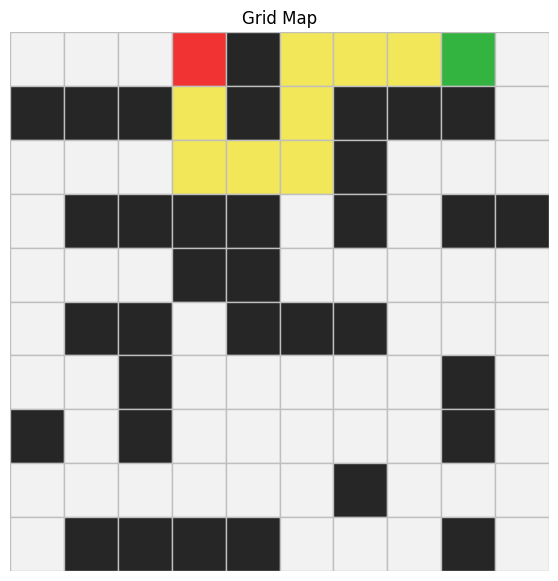

,Algorithm,Status,Limit,Solution depth,Solution cost,Nodes expanded,Max frontier/stack,Reached states
0,BFS,success,NaN,9,9.0,22,4,26
1,DFS,success,NaN,35,35.0,38,12,50
2,DLS,success,20.0,9,9.0,92,21,0
3,IDS,success,9.0,9,9.0,91,10,0


In [ ]:
# Custom Scenario 1
custom_grid_1 = [
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
    [1, 1, 1, 0, 1, 0, 1, 1, 1, 0],
    [0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
    [0, 1, 1, 1, 1, 0, 1, 0, 1, 1],
    [0, 0, 0, 1, 1, 0, 0, 0, 0, 0],
    [0, 1, 1, 0, 1, 1, 1, 0, 0, 0],
    [0, 0, 1, 0, 0, 0, 0, 0, 1, 0],
    [1, 0, 1, 0, 0, 0, 0, 0, 1, 0],
    [0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
    [0, 1, 1, 1, 1, 0, 0, 0, 1, 0],
]

custom_start_1 = (0,3)
custom_goal_1 = (0,8)

bfs = BreadthFirstSearch()
dfs = DepthFirstSearch()
dls = DepthLimitedSearch()
ids = IterativeDeepeningSearch()

custom_problem_1 = GridProblem(custom_grid_1, custom_start_1, custom_goal_1)

custom_results_1 = [
    bfs.search(custom_problem_1),
    dfs.search(custom_problem_1),
    dls.search(custom_problem_1, limit=20),
    ids.search(custom_problem_1, max_depth=40)

]

suggested_path = [(0, 3), (1, 3), (2, 3), (2, 4), (2, 5), (1, 5), (0, 5), (0, 6), (0, 7), (0, 8)]

plot_path(custom_grid_1, custom_start_1, custom_goal_1, suggested_path)
print()

show_results(custom_results_1)

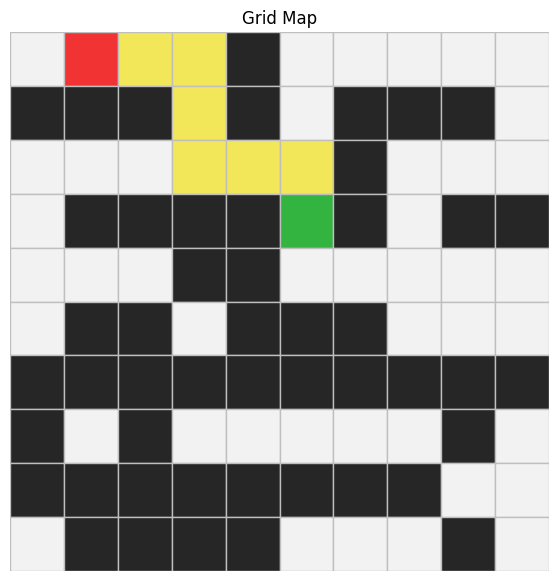

,Algorithm,Status,Limit,Solution depth,Solution cost,Nodes expanded,Max frontier/stack,Reached states
0,BFS,success,NaN,7,7.0,10,3,13
1,DFS,success,NaN,7,7.0,16,3,17
2,DLS,success,20.0,7,7.0,31,21,0
3,IDS,success,7.0,7,7.0,37,8,0


In [ ]:
# Custom Scenario 2
custom_grid_2 = [
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
    [1, 1, 1, 0, 1, 0, 1, 1, 1, 0],
    [0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
    [0, 1, 1, 1, 1, 0, 1, 0, 1, 1],
    [0, 0, 0, 1, 1, 0, 0, 0, 0, 0],
    [0, 1, 1, 0, 1, 1, 1, 0, 0, 0],
    [1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
    [1, 0, 1, 0, 0, 0, 0, 0, 1, 0],
    [1, 1, 1, 1, 1, 1, 1, 1, 0, 0],
    [0, 1, 1, 1, 1, 0, 0, 0, 1, 0],
]

custom_start_2 = (0,1)
custom_goal_2 = (3,5)

bfs = BreadthFirstSearch()
dfs = DepthFirstSearch()
dls = DepthLimitedSearch()
ids = IterativeDeepeningSearch()

custom_problem_2 = GridProblem(custom_grid_2, custom_start_2, custom_goal_2)

custom_results_2 = [
    bfs.search(custom_problem_2),
    dfs.search(custom_problem_2),
    dls.search(custom_problem_2, limit=20),
    ids.search(custom_problem_2, max_depth=40)

]

suggested_path = [(0, 1), (0, 2), (0, 3), (1, 3), (2, 3), (2, 4), (2, 5), (3, 5)]

plot_path(custom_grid_2, custom_start_2, custom_goal_2, suggested_path)
print()


show_results(custom_results_2)


# **REFLECTION QUESTIONS**

## 15.1 Problem Formulation
1. A state refers to a cell in the grid problem. It is a tuple of two coordinates with a row and column representing the position of the drone.

2. An action is a change in position from one grid position to another that the drone can perform. The actions in this given scenario were ('UP', 'DOWN', 'LEFT' , 'RIGHT')

3. It returns the next state (position tuple) after performing an action to a given state.

4. It's a form of encapsulation that allows for the same problem to be passed to multiple search algorithms without having to reproduce the same problem structure for each algorithm.


## 15.2 BFS
1. It ensures that the algorithm fully expands and explores all nodes at a given depth before exploring nodes at higher depths.

2. This is because BFS explores layer by layer in a uniform manner esnuring that the goal state can be found within a set number of steps.

3. It tracks the states that have allready been exlpored to prevent BFS from exploring those states again.


## 15.3 DFS
1. A LIFO stack ensures that the DFS algorithm always expands the last and deepest unexplored node first, ensuring that it continually moves down through a single path.

2. No. This is because the DFS algorithm traverses down one branch before checking others meaning that there is a high possiblity of exploring branches that do not contain the goal state.

3. In wide state spaces or problem scenarios where there is shallow depth. Essentially, in scenarios where the branching factor is high since it would only store nodes on a single branch compared to BFS which would store an entire layer.

4. In extremely large (close to infinite) state spaces. This is because there is a chance that the DFS algorithm would go down a one large branch with several nodes all of which don't contain the goal state before now iterating through other nodes.


## 15.4 DLS
1. The algorithm will terminate before finding a solution at every single iteration.

2. A cutoff is a place holder used to indicate that a DLS iteration terminated because it reached the maximum allowed depth without finding a goal. Signalling that the goal state may still remain on that branch it terminated on.

3. DLS simply lpaces a limit (maximum allowe depth) on how deep it will traverse down a branch.

4. To save memory and time. Without a data structure like a reached set, DLS is more effecient and takes less memory. It simply checks if the current state is one it has traversed ebfore.



## 15.5 IDS
1. It allows the algorithm to gain benefits from both DFS and BFS algorithms. On one end, it allow sfor low memoery overhead of DFS and also allows for completeness (reaching a goal state)

2. Because IDS continually increments the limit until the goal state is found. Even if early iterations fail due to a low limit, the goal state is eventually found.

3. This is because IDS just runs single iterations of the DLS algorithm which are more memory effecient than BFS due to path-cycle checking. BFS stores the whole layer of nodes whereas DLS which forms IDS just checks that the current node has not been explored before.

4. It leads to redundant generation of uppper-level nodes which are unlikely to contain the goal state. However at the root and immediate sub nodes, the number of nodes are quite small leading to less burden on memory storage.



## 15.6 Real-Word Drone Context
1. Accounting for factors such as wind resistance, obstacles, signal connectivity and battery consumption might help one to evaluate which paths are more practical than others.

2. Since the grid is unweighted and all moves are equally costly, I would opt for the BFS since finding a goal state is guaranteed in the most optimal path.

3. The DLS algorithm since it naturally allows for a limit to be placed on the searching.

4. This grid does not account for dynamic environments such as real world scenarios like different weather conditions.


